## TASK 1 - Experimentation With Colour Spaces


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import cv2
from skimage import io, color, filters, transform, exposure
from skimage.util import img_as_float, img_as_ubyte
import os

# Set up plotting style
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

image_files = ['images/images/task1/floresVermelhas.bmp', 
               'images/images/task1/folhasVerdes.bmp', 
               'images/images/task1/nenufares.bmp', 
               'images/images/task1/testRGB.bmp']

### 1.1. RGB to HSV Conversion
In this section, we convert RGB images to the HSV color space and visualize each channel. H represents hue, S represents Saturation and V represents brightness.


Processing images/images/task1/floresVermelhas.bmp...


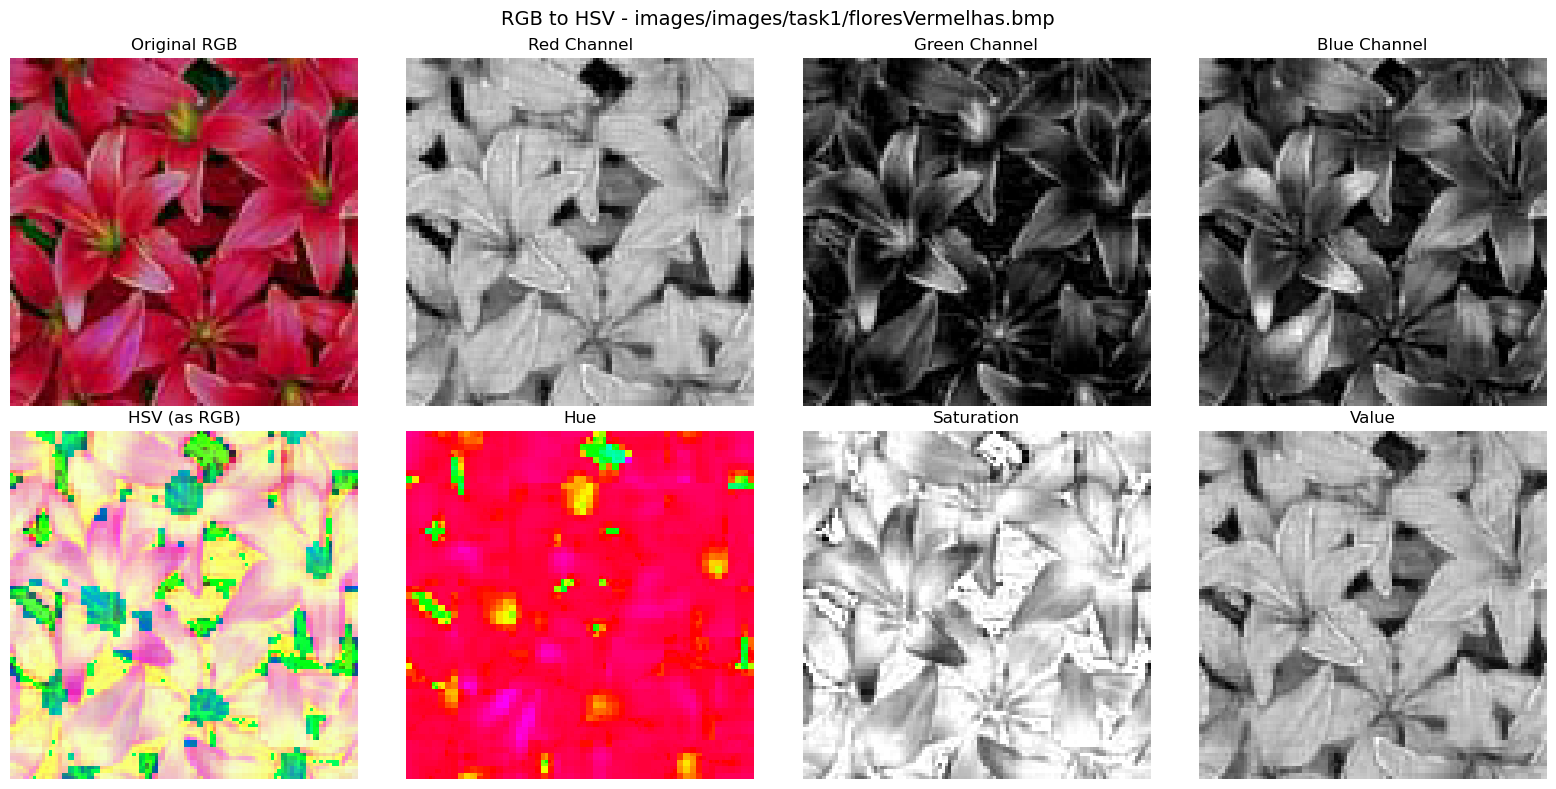


Processing images/images/task1/folhasVerdes.bmp...


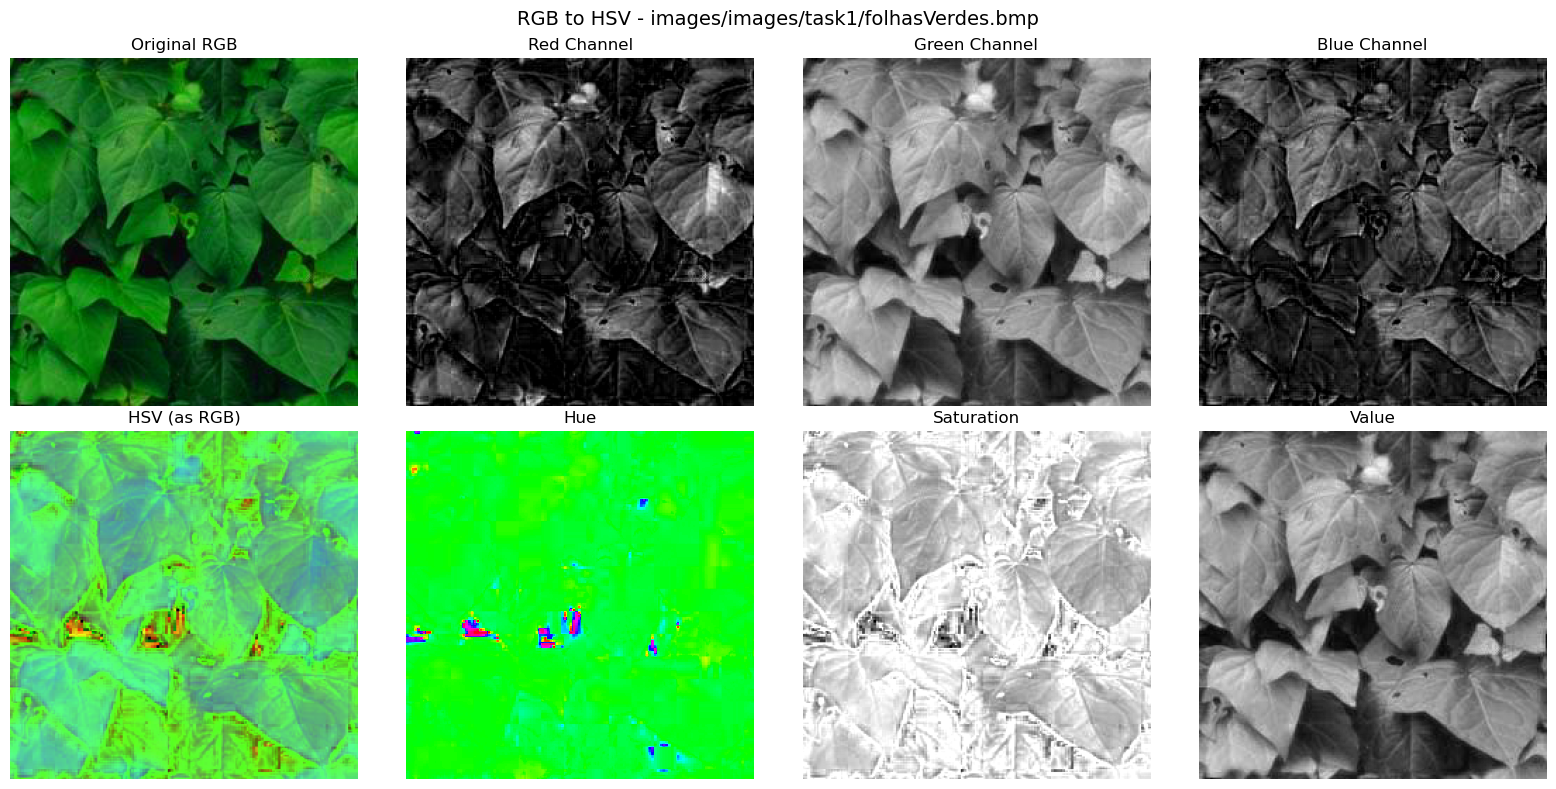


Processing images/images/task1/nenufares.bmp...


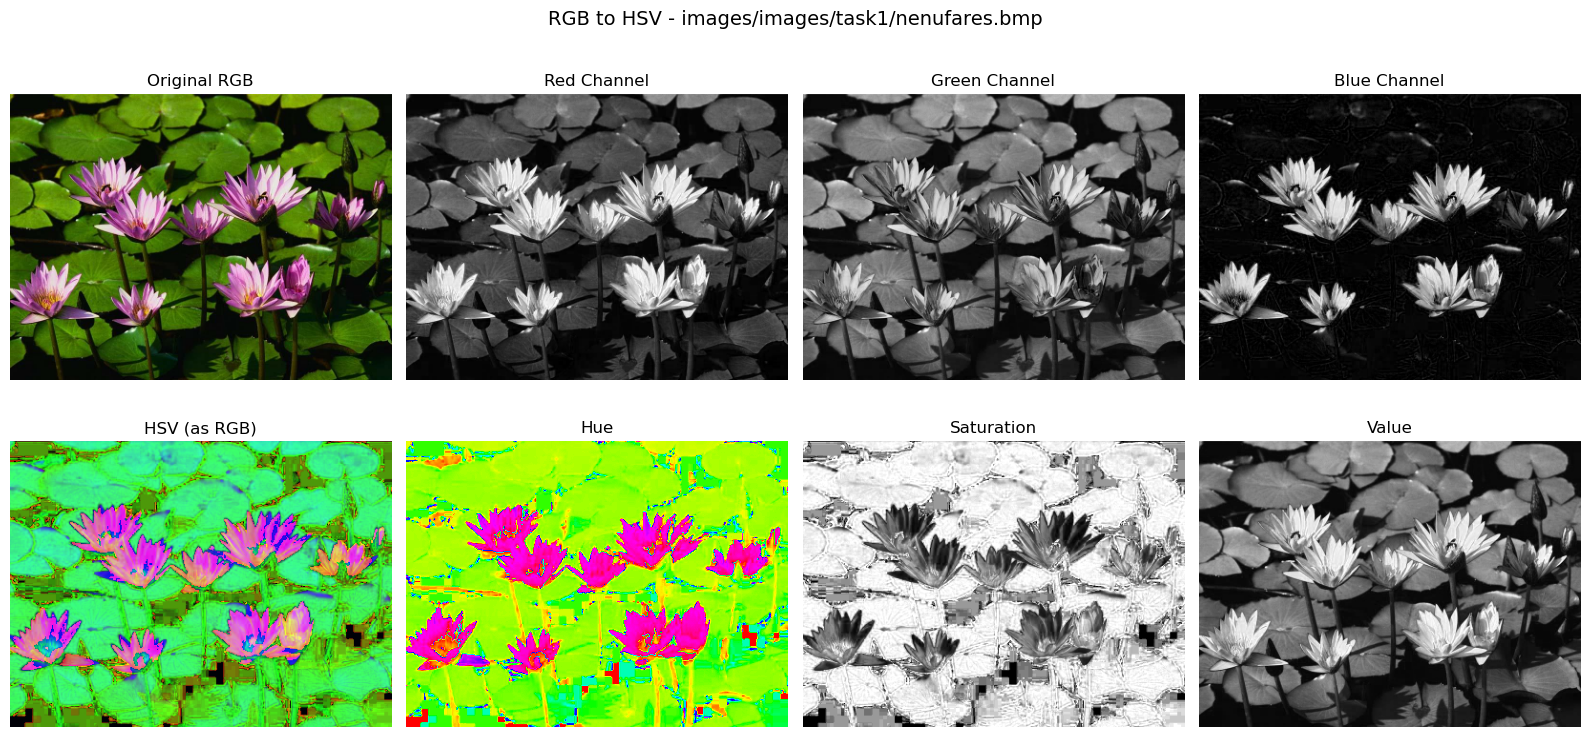


Processing images/images/task1/testRGB.bmp...


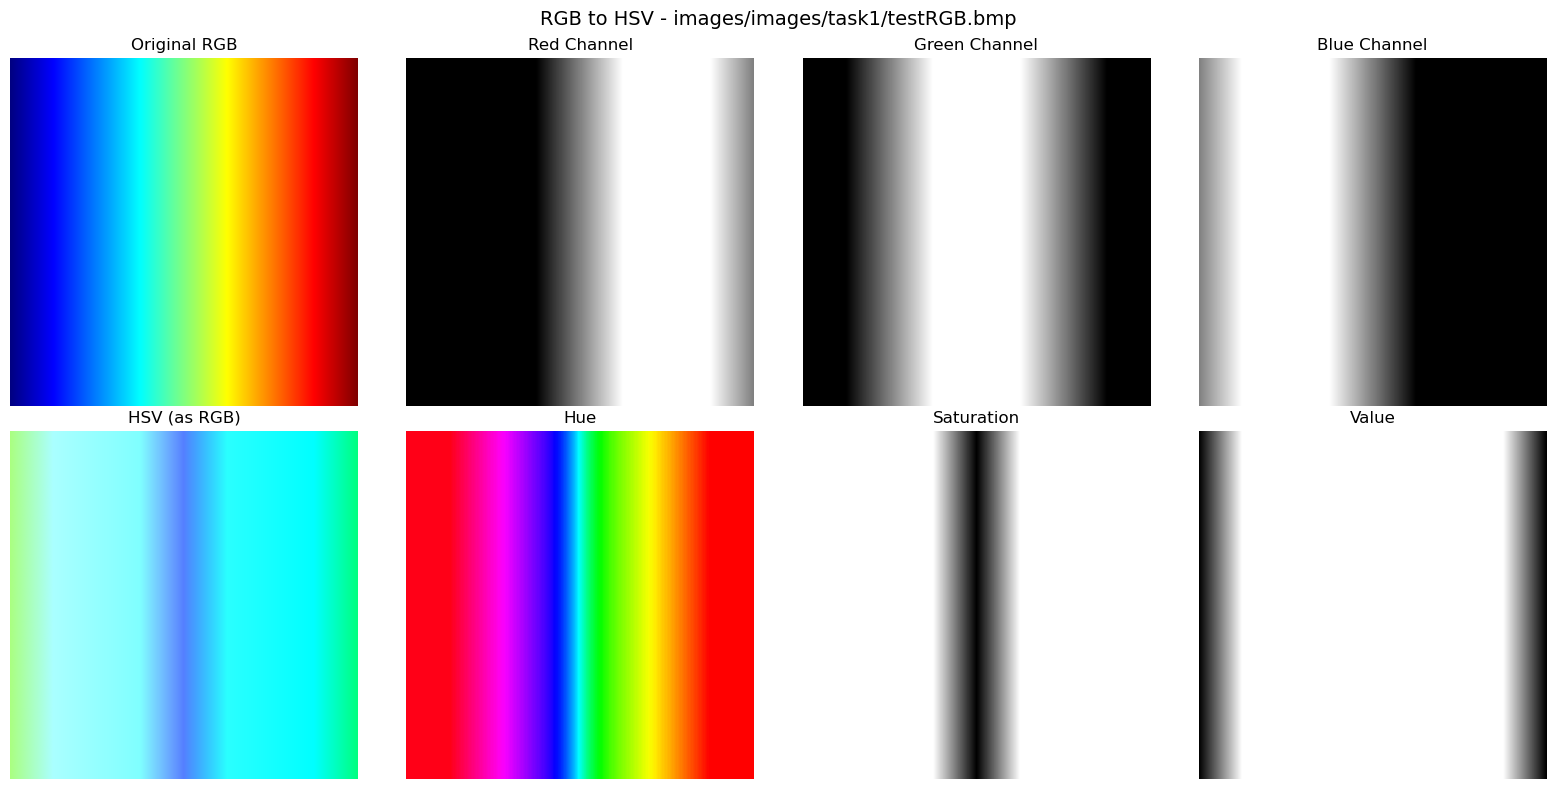

In [4]:
# Batch RGB to HSV conversion and visualization for multiple images
for img_file in image_files:
    # 1.1.1 Import and display original image
    img = io.imread(img_file)
    if img.ndim == 3 and img.shape[2] == 4:  # Remove alpha channel if present
        img = img[:, :, :3]
    print(f'\nProcessing {img_file}...')
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f'RGB to HSV - {img_file}', fontsize=14)
    # 1.1.1 Display original RGB
    axes[0, 0].imshow(img)
    axes[0, 0].set_title('Original RGB')
    axes[0, 0].axis('off')
    # 1.1.2 Separate and display RGB components
    for j, color_name in enumerate(['Red', 'Green', 'Blue']):
        component = np.zeros_like(img)
        component = img[:, :, j]
        axes[0, j+1].imshow(component, cmap='gray')
        axes[0, j+1].set_title(f'{color_name} Channel')
        axes[0, j+1].axis('off')
    # 1.1.3 Convert to HSV and display
    img_float = img_as_float(img)
    img_hsv = color.rgb2hsv(img_float)
    axes[1, 0].imshow(img_hsv)
    axes[1, 0].set_title('HSV (as RGB)')
    axes[1, 0].axis('off')
    # 1.1.4 Separate and display HSV components
    hsv_titles = ['Hue', 'Saturation', 'Value']
    hsv_cmaps = ['hsv', 'gray', 'gray']
    for j in range(3):
        axes[1, j+1].imshow(img_hsv[:, :, j], cmap=hsv_cmaps[j])
        axes[1, j+1].set_title(f'{hsv_titles[j]}')
        axes[1, j+1].axis('off')
    plt.tight_layout()
    plt.show()  

### 1.2. RGB to YCbCr Conversion
In this section, we convert RGB images to the YCbCr color space and visualize each channel. Y represents luminance, while Cb and Cr represent chrominance (color difference signals).


Processing images/images/task1/floresVermelhas.bmp...


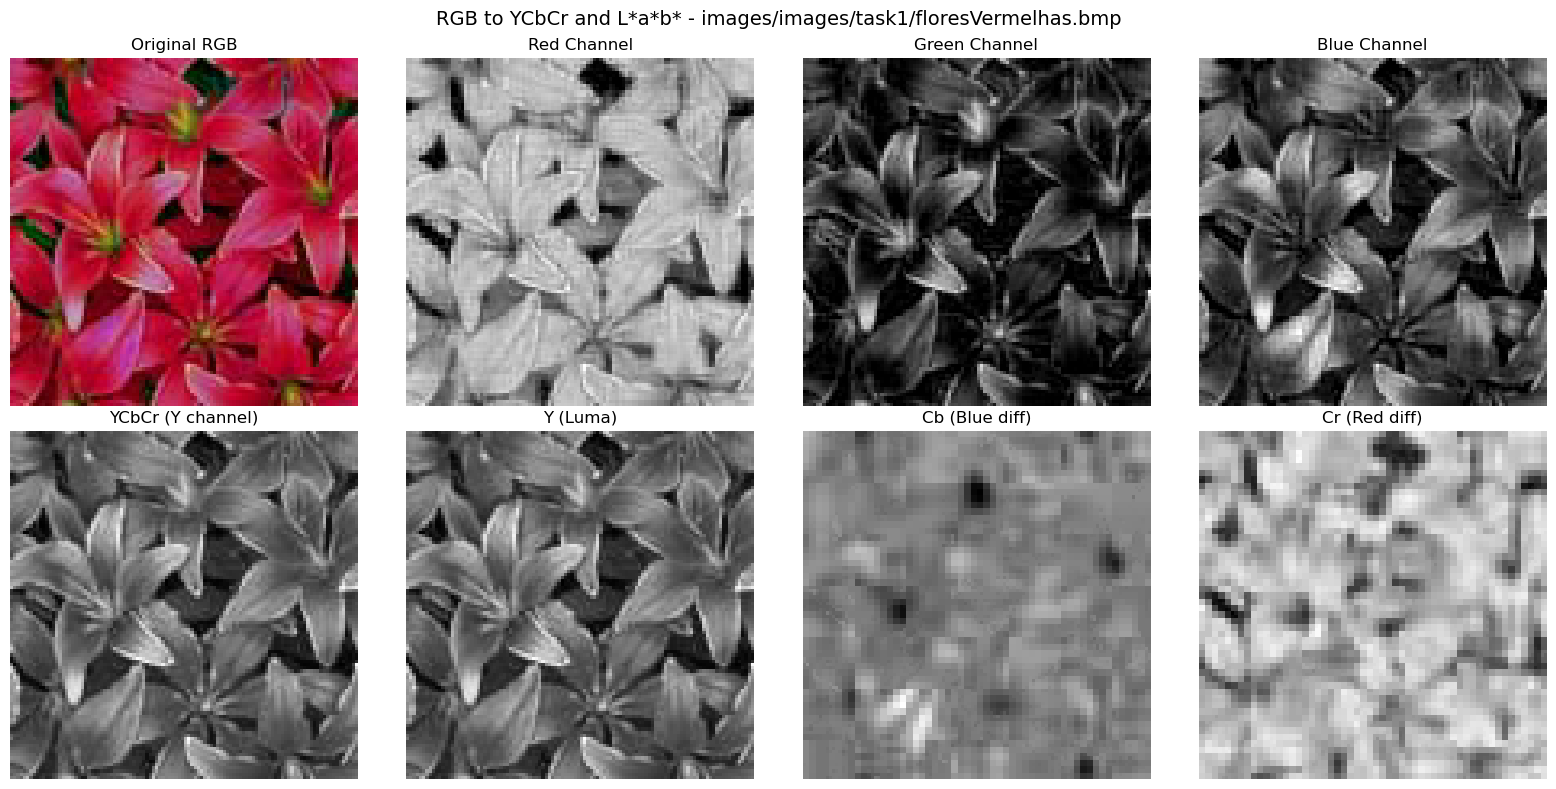


Processing images/images/task1/folhasVerdes.bmp...


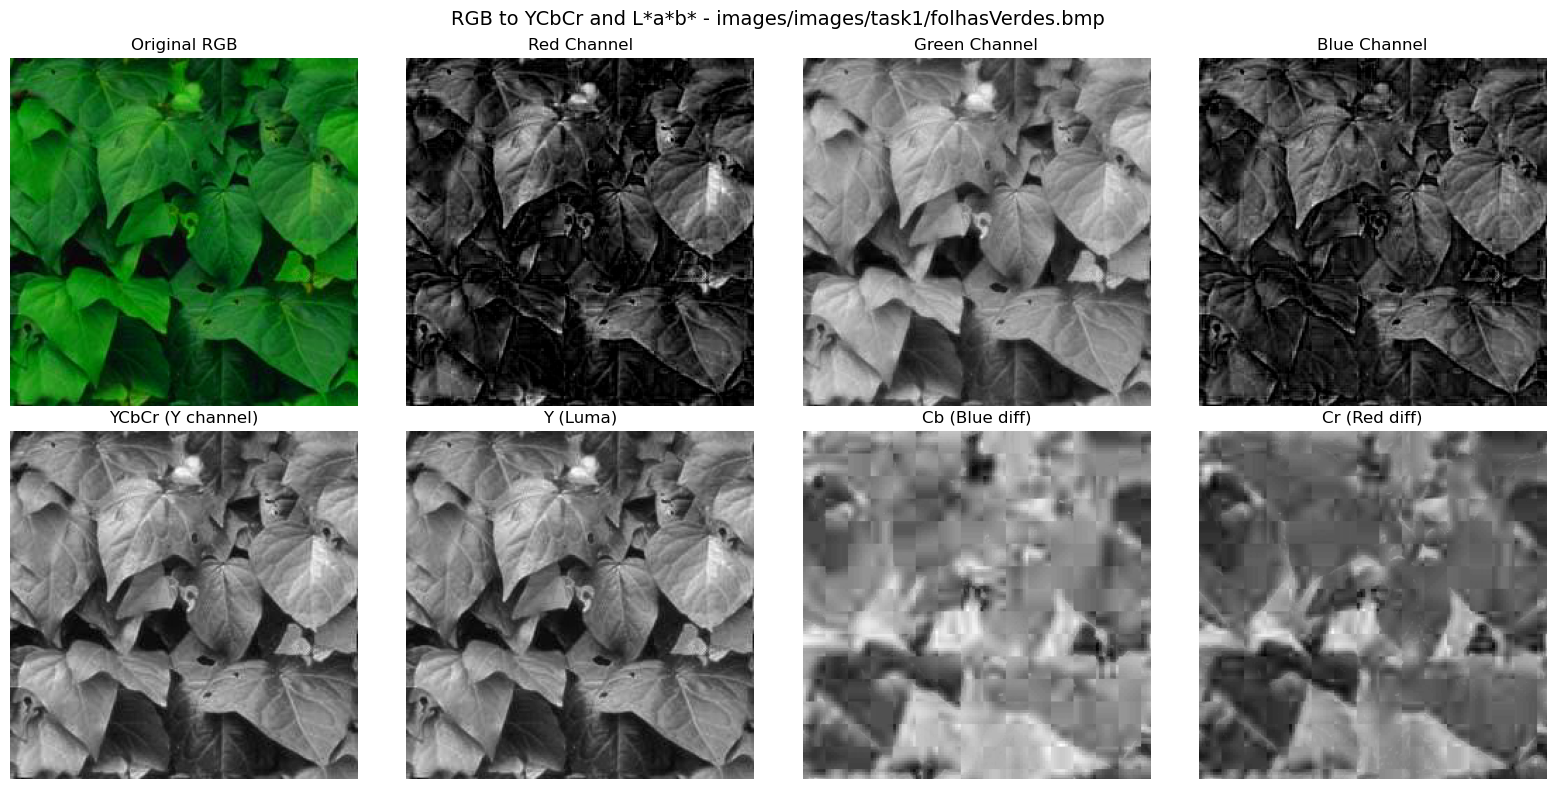


Processing images/images/task1/nenufares.bmp...


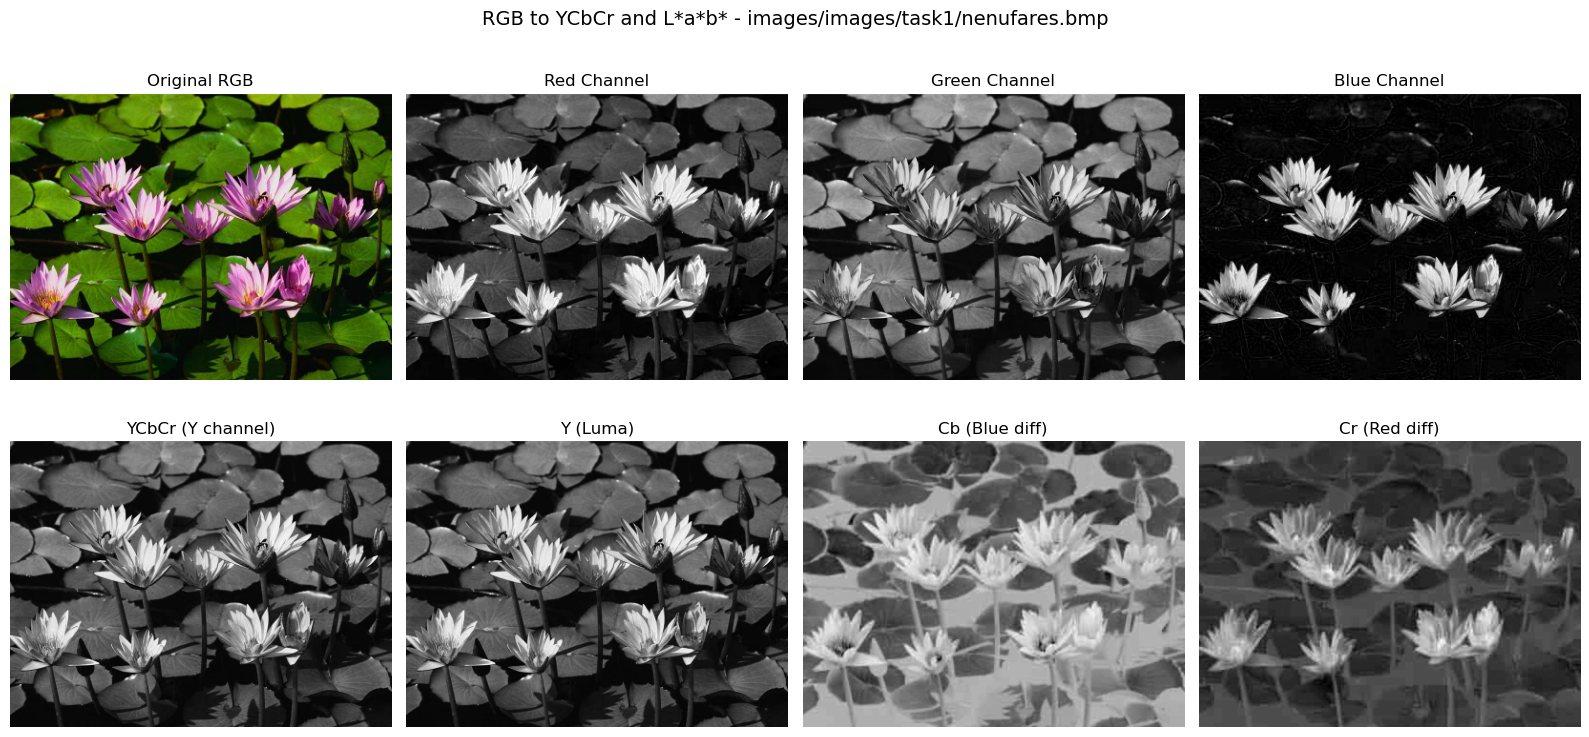


Processing images/images/task1/testRGB.bmp...


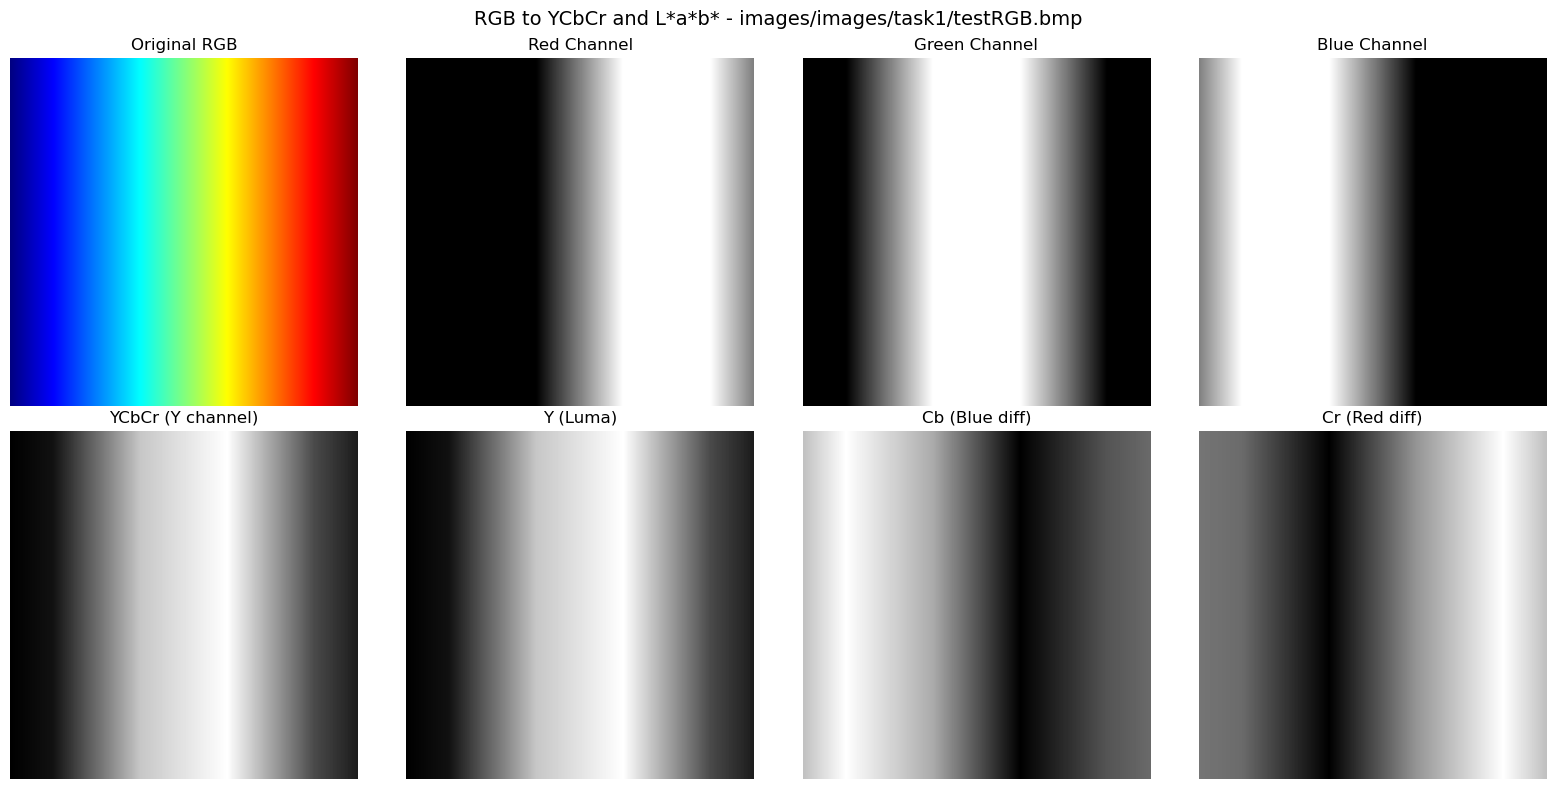

In [5]:
for img_file in image_files:
    # 1.1.1 Import and display original image
    img = io.imread(img_file)
    if img.ndim == 3 and img.shape[2] == 4:  # Remove alpha channel if present
        img = img[:, :, :3]
    
    print(f'\nProcessing {img_file}...')
    
    # Create figure with 2 rows, 4 columns
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f'RGB to YCbCr and L*a*b* - {img_file}', fontsize=14)
    
    # 1.1.1 Display original RGB
    axes[0, 0].imshow(img)
    axes[0, 0].set_title('Original RGB')
    axes[0, 0].axis('off')
    
    # 1.1.2 Separate and display RGB components
    for j, color_name in enumerate(['Red', 'Green', 'Blue']):
        component = np.zeros_like(img)
        component = img[:, :, j]
        axes[0, j+1].imshow(component, cmap='gray')
        axes[0, j+1].set_title(f'{color_name} Channel')
        axes[0, j+1].axis('off')
    
    # Convert to float for color space conversions
    img_float = img_as_float(img)
    
    # 1.1.3 Convert to YCbCr and display
    img_ycbcr = color.rgb2ycbcr(img_float)
    axes[1, 0].imshow(img_ycbcr[:, :, 0], cmap='gray')  # Y (luma) as grayscale
    axes[1, 0].set_title('YCbCr (Y channel)')
    axes[1, 0].axis('off')
    
    # 1.1.4 Separate and display YCbCr components
    ycbcr_titles = ['Y (Luma)', 'Cb (Blue diff)', 'Cr (Red diff)']
    ycbcr_cmaps = ['gray', 'gray', 'gray']
    for j in range(3):
        axes[1, j+1].imshow(img_ycbcr[:, :, j], cmap=ycbcr_cmaps[j])
        axes[1, j+1].set_title(f'{ycbcr_titles[j]}')
        axes[1, j+1].axis('off')
    
    plt.tight_layout()
    plt.show()

### 1.3. RGB to L*a*b Conversion
In this section, we convert RGB images to the L*a*b color space and visualize each channel. L is the luminosity level, a is color channel along the green-red axis and b is the color channel along the blue-yellow axis


Processing images/images/task1/floresVermelhas.bmp...


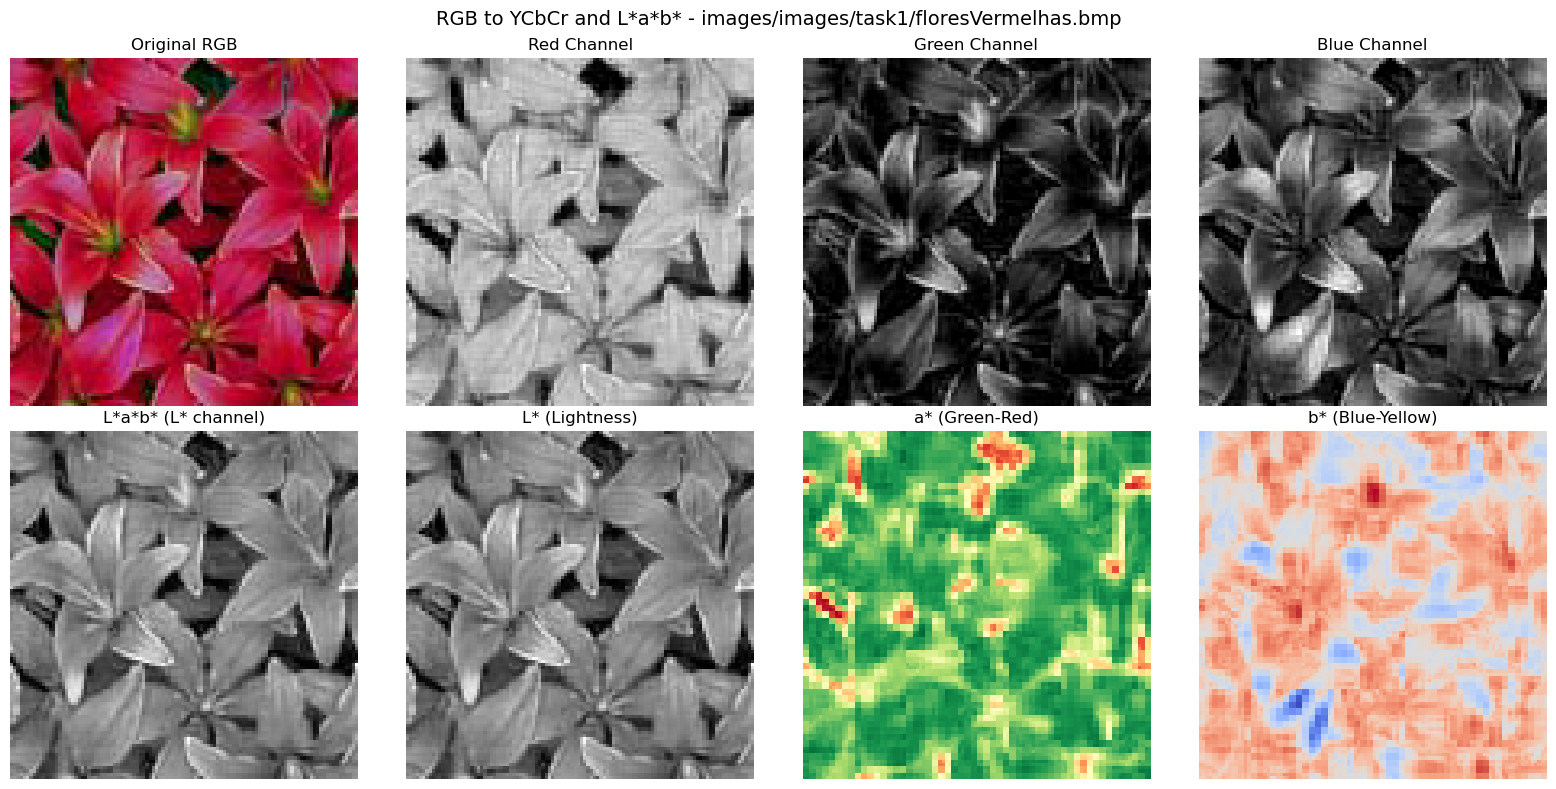


Processing images/images/task1/folhasVerdes.bmp...


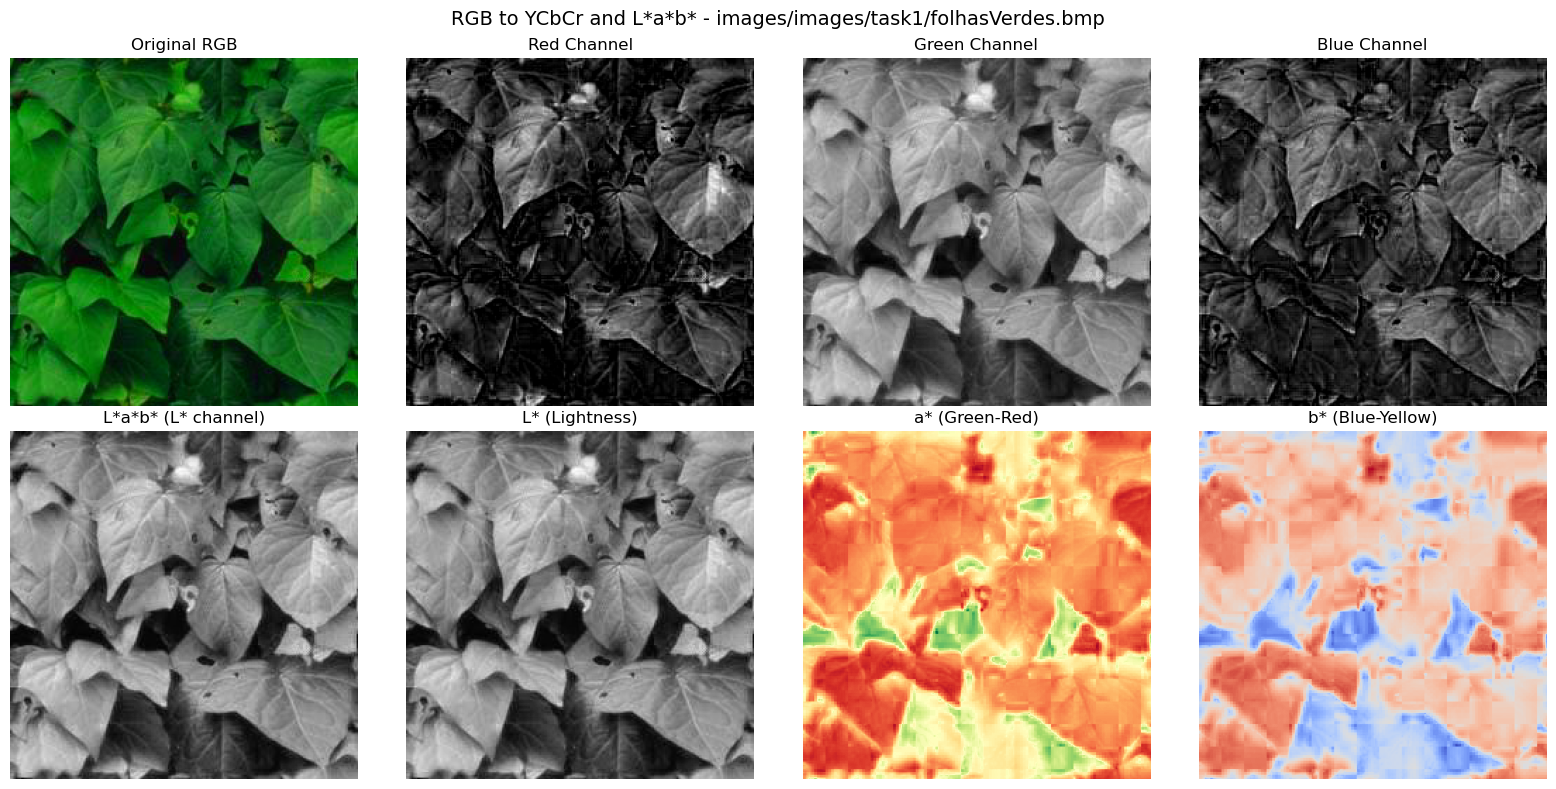


Processing images/images/task1/nenufares.bmp...


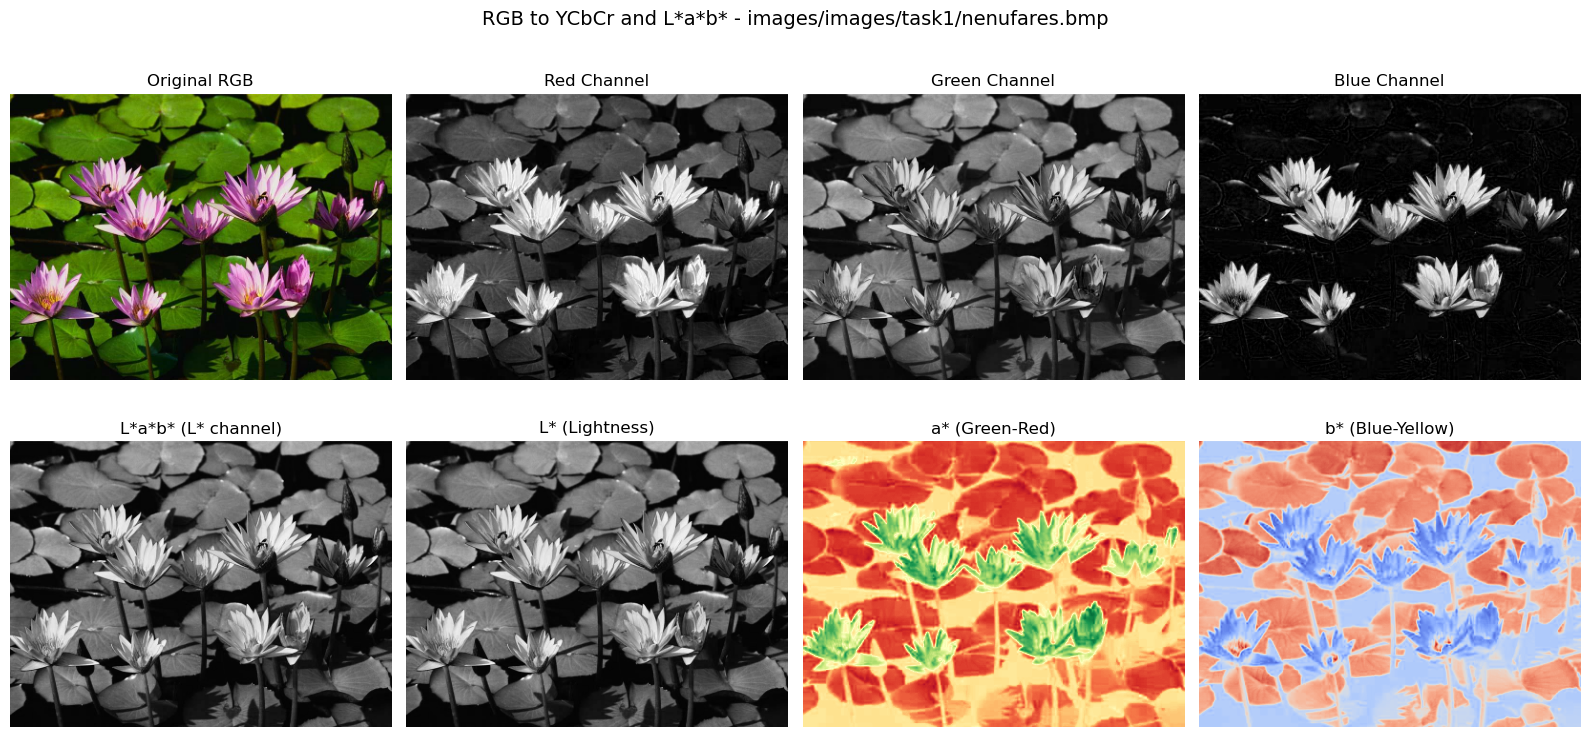


Processing images/images/task1/testRGB.bmp...


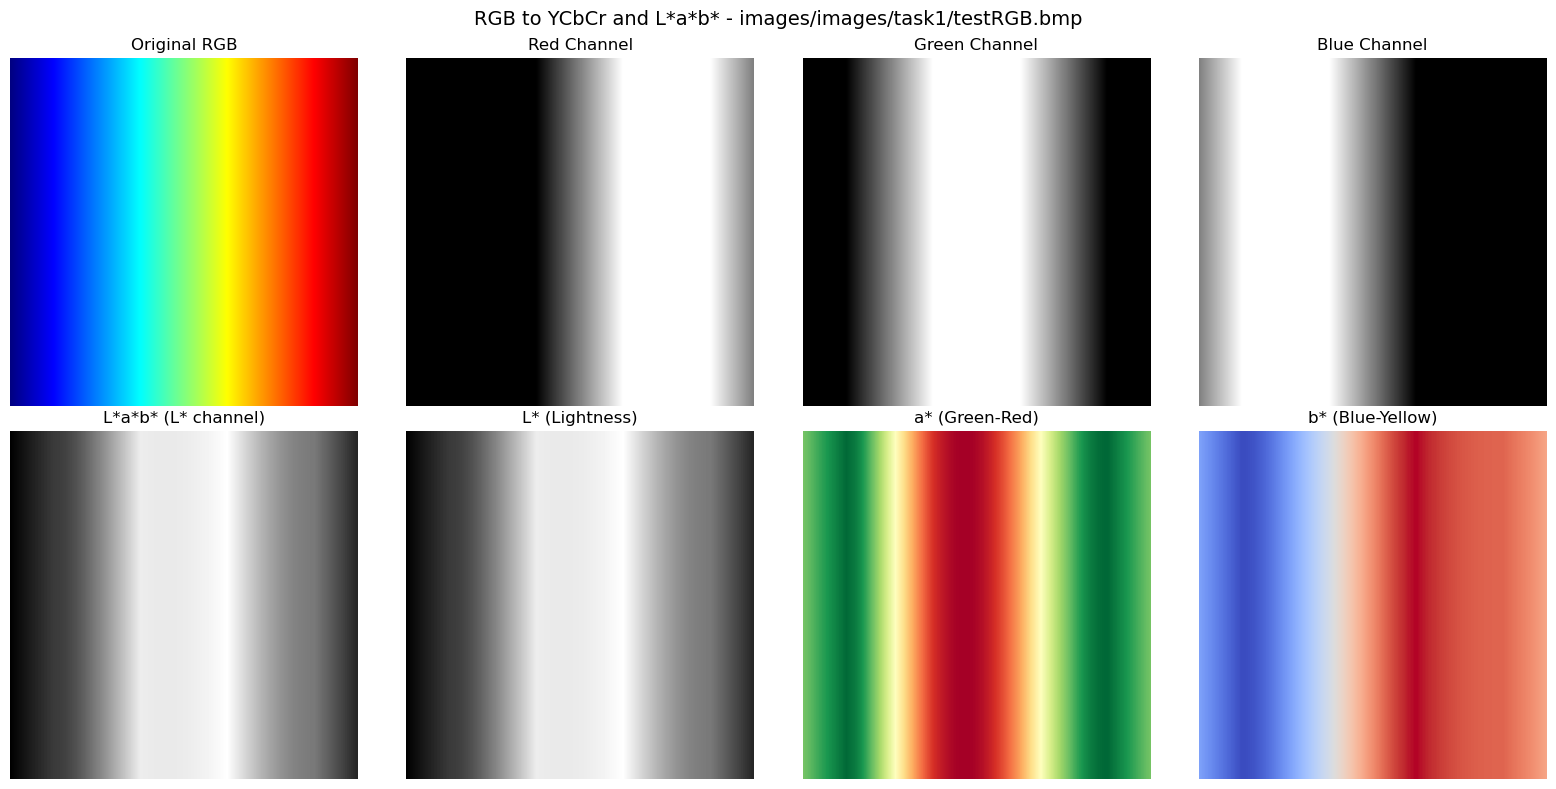

In [6]:
for img_file in image_files:    
    # 1.1.1 Import and display original image
    img = io.imread(img_file)
    if img.ndim == 3 and img.shape[2] == 4:  # Remove alpha channel if present
        img = img[:, :, :3]
    
    print(f'\nProcessing {img_file}...')
    
    # Create figure with 2 rows, 4 columns
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f'RGB to YCbCr and L*a*b* - {img_file}', fontsize=14)
    
    # 1.1.1 Display original RGB
    axes[0, 0].imshow(img)
    axes[0, 0].set_title('Original RGB')
    axes[0, 0].axis('off')
    
    # 1.1.2 Separate and display RGB components (repeat)
    for j, color_name in enumerate(['Red', 'Green', 'Blue']):
        component = np.zeros_like(img)
        component = img[:, :, j]
        axes[0, j+1].imshow(component,cmap = 'gray')
        axes[0, j+1].set_title(f'{color_name} Channel')
        axes[0, j+1].axis('off')
    
    # 1.1.5 Convert to L*a*b* and display
    img_float = img_as_float(img)
    img_lab = color.rgb2lab(img_float)
    axes[1, 0].imshow(img_lab[:, :, 0], cmap='gray')  # L* channel as grayscale
    axes[1, 0].set_title('L*a*b* (L* channel)')
    axes[1, 0].axis('off')
    
    # 1.1.6 Separate and display L*a*b* components
    lab_titles = ['L* (Lightness)', 'a* (Green-Red)', 'b* (Blue-Yellow)']
    lab_cmaps = ['gray', 'RdYlGn', 'coolwarm']
    for j in range(3):
        axes[1, j+1].imshow(img_lab[:, :, j], cmap=lab_cmaps[j])
        axes[1, j+1].set_title(f'{lab_titles[j]}')
        axes[1, j+1].axis('off')
    
    plt.tight_layout()
    plt.show()

## Histogram

# Part 2: Variation of Image Spatial Dimensions

This part explores image resizing methods and their effects on frequency content.

In [ ]:
# Import additional libraries for frequency analysis
from scipy.fft import fft2, fftshift

# Generate zone plate test image
def generate_zoneplate(size=512):
    """
    Generate a zone plate test image - a circular pattern with increasing spatial frequency
    useful for detecting aliasing artifacts
    """
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)
    X, Y = np.meshgrid(x, y)
    
    # Distance from center
    R = np.sqrt(X**2 + Y**2)
    
    # Zone plate pattern: frequency increases with radius
    zoneplate = 0.5 + 0.5 * np.cos(50 * np.pi * R**2)
    
    return zoneplate

# Create and display the zone plate
zoneplate = generate_zoneplate(512)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(zoneplate, cmap='gray')
plt.title('Zone Plate Test Image (512x512)')
plt.axis('off')

# Show FFT magnitude
fft_zp = fftshift(fft2(zoneplate))
magnitude = np.log(1 + np.abs(fft_zp))

plt.subplot(1, 2, 2)
plt.imshow(magnitude, cmap='viridis')
plt.title('FFT Magnitude (log scale)')
plt.axis('off')

plt.tight_layout()
plt.show()

## 2.1 Naive Resizing

Downsample by removing pixels (take every 2nd pixel). Upsample by pixel replication (nearest-neighbor).

In [ ]:
# Test naive resizing on zone plate
print("Testing Naive Resizing on Zone Plate")
print("="*60)

# Downsample: take every 2nd pixel
zp_downsampled = zoneplate[::2, ::2]
print(f"Original size: {zoneplate.shape}")
print(f"Downsampled size: {zp_downsampled.shape}")

# Upsample: repeat each pixel
zp_upsampled = np.repeat(np.repeat(zp_downsampled, 2, axis=0), 2, axis=1)
print(f"Upsampled size: {zp_upsampled.shape}")

# Compute FFTs
fft_orig = np.log(1 + np.abs(fftshift(fft2(zoneplate))))
fft_down = np.log(1 + np.abs(fftshift(fft2(zp_downsampled))))
fft_up = np.log(1 + np.abs(fftshift(fft2(zp_upsampled))))

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Images
axes[0, 0].imshow(zoneplate, cmap='gray')
axes[0, 0].set_title(f'Original\n{zoneplate.shape[0]}x{zoneplate.shape[1]}')
axes[0, 0].axis('off')

axes[0, 1].imshow(zp_downsampled, cmap='gray')
axes[0, 1].set_title(f'Downsampled (every 2nd pixel)\n{zp_downsampled.shape[0]}x{zp_downsampled.shape[1]}')
axes[0, 1].axis('off')

axes[0, 2].imshow(zp_upsampled, cmap='gray')
axes[0, 2].set_title(f'Upsampled (pixel replication)\n{zp_upsampled.shape[0]}x{zp_upsampled.shape[1]}')
axes[0, 2].axis('off')

# Row 2: FFT Magnitudes
axes[1, 0].imshow(fft_orig, cmap='viridis')
axes[1, 0].set_title('FFT Magnitude')
axes[1, 0].axis('off')

axes[1, 1].imshow(fft_down, cmap='viridis')
axes[1, 1].set_title('FFT Magnitude')
axes[1, 1].axis('off')

axes[1, 2].imshow(fft_up, cmap='viridis')
axes[1, 2].set_title('FFT Magnitude')
axes[1, 2].axis('off')

plt.suptitle('Naive Resizing - Zone Plate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📝 Observations - Zone Plate:")
print("- Downsampling: Severe aliasing visible - high frequencies fold back as false patterns")
print("- FFT shows frequency components beyond Nyquist limit causing aliasing")
print("- Upsampling: Blocky artifacts due to pixel replication")
print("- FFT shows missing high frequencies (blur) but repeated spectrum patterns")

In [ ]:
# Test naive resizing on real images from Part 1
for img_file in image_files:
    print(f"\nProcessing: {img_file}")
    
    # Load and convert to grayscale
    img = io.imread(img_file)
    img_gray = color.rgb2gray(img)
    
    # Downsample: take every 2nd pixel
    img_down = img_gray[::2, ::2]
    
    # Upsample: repeat each pixel
    img_up = np.repeat(np.repeat(img_down, 2, axis=0), 2, axis=1)
    
    # Compute FFTs
    fft_orig = np.log(1 + np.abs(fftshift(fft2(img_gray))))
    fft_down = np.log(1 + np.abs(fftshift(fft2(img_down))))
    fft_up = np.log(1 + np.abs(fftshift(fft2(img_up))))
    
    # Visualize
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Row 1: Images
    axes[0, 0].imshow(img_gray, cmap='gray')
    axes[0, 0].set_title(f'Original\n{img_gray.shape[0]}x{img_gray.shape[1]}')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(img_down, cmap='gray')
    axes[0, 1].set_title(f'Downsampled\n{img_down.shape[0]}x{img_down.shape[1]}')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(img_up, cmap='gray')
    axes[0, 2].set_title(f'Upsampled\n{img_up.shape[0]}x{img_up.shape[1]}')
    axes[0, 2].axis('off')
    
    # Row 2: FFT Magnitudes
    axes[1, 0].imshow(fft_orig, cmap='viridis')
    axes[1, 0].set_title('FFT Magnitude')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(fft_down, cmap='viridis')
    axes[1, 1].set_title('FFT Magnitude')
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(fft_up, cmap='viridis')
    axes[1, 2].set_title('FFT Magnitude')
    axes[1, 2].axis('off')
    
    plt.suptitle(f'Naive Resizing - {img_file.split("/")[-1]}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n📝 Observations - Real Images:")
print("- Downsampling: Loss of detail, potential aliasing in areas with fine textures")
print("- Natural images less prone to severe aliasing than zone plate due to lower high-frequency content")
print("- Upsampling: Blocky appearance, staircase artifacts on edges")
print("- FFT shows reduced frequency range after downsampling, replication artifacts after upsampling")